In [ ]:
!pip install -q category_encoders


In [ ]:
!pip install catboost optuna

In [ ]:
from google.colab import drive
import seaborn as sns
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


drive.mount('/content/drive')

import pandas as pd

client = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Client.csv')

record = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Record.csv')

print(client.shape)

print(record.shape)

print("\nCLIENT COLUMNS")

print(client.columns.tolist())

print("\nRECORD COLUMNS")

print(record.columns.tolist())


client_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Client.csv')
record_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Record.csv')

"""
UTokyo GCI 2026: Customer Churn Prediction and Business Value Optimization
Target Portal: Omnicampus
Description: This script joins telecom usage and demographic tables, handles missing values, manages class imbalance, trains an XGBoost model, optimizes the decision threshold using an economic utility model, and calculates the annual financial impact.
"""
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from xgboost import XGBClassifier
import category_encoders as ce
print("successfully installed...")

def run_churn_pipeline():
    # 1. DATA INTEGRATION
    print("Loading and joining datasets...")
    # Load 'Client.csv' and 'Record.csv'
    client_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Client.csv')
    record_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Record.csv')

    # Join them on 'Customer_ID'
    data = pd.merge(record_df, client_df, on='Customer_ID', how='inner')

    target = 'churn'
    X = data.drop(columns=['Customer_ID', target])
    y = data[target]

    # Split them into stratified Train (70%), Validation (15%), and Test (15%) partitions.
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

    # 2. PREPROCESSING
    print("Preprocessing data...")
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    high_cardinality_cols = [col for col in cat_cols if X_train[col].nunique() > 2]
    binary_cols = [col for col in cat_cols if X_train[col].nunique() <= 2]

    # Implement median imputation for missing numerical data
    for col in num_cols:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_val[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

    # Implement mode imputation for categorical data
    for col in cat_cols:
        mode_val = X_train[col].mode()[0]
        X_train[col].fillna(mode_val, inplace=True)
        X_val[col].fillna(mode_val, inplace=True)
        X_test[col].fillna(mode_val, inplace=True)

    # Implement target encoding for high-cardinality features
    if high_cardinality_cols:
        te = ce.TargetEncoder(cols=high_cardinality_cols)
        X_train[high_cardinality_cols] = te.fit_transform(X_train[high_cardinality_cols], y_train)
        X_val[high_cardinality_cols] = te.transform(X_val[high_cardinality_cols])
        X_test[high_cardinality_cols] = te.transform(X_test[high_cardinality_cols])

    # Implement label encoding for binary variables
    for col in binary_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_val[col] = X_val[col].astype(str).map(lambda s: le_dict.get(s, -1))
        X_test[col] = X_test[col].astype(str).map(lambda s: le_dict.get(s, -1))

    # 3. XGBOOST MODELING
    print("Training XGBoost Classifier...")
    # Calculate scale_pos_weight based on the training set's class distribution
    neg_count = np.sum(y_train == 0)
    pos_count = np.sum(y_train == 1)
    scale_weight = neg_count / pos_count

    # Train an XGBClassifier with n_estimators=500, learning_rate=0.05, max_depth=6, scale_pos_weight=scale_weight
    xgb_clf = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_weight,
        eval_metric='auc',
        random_state=42
    )
    xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # 4. UTILITY MODELING & METRICS
    y_prob = xgb_clf.predict_proba(X_test)[:, 1]

    # Calculate the optimal probability threshold using decision theory: theta* = C_FP / (C_FP + C_FN)
    C_FP = 150.0   # Campaign cost
    C_FN = 1360.0  # CAC of $300 + lost LTV of $1,060
    theta_opt = C_FP / (C_FP + C_FN)

    y_pred_base = (y_prob >= 0.50).astype(int)
    y_pred_opt = (y_prob >= theta_opt).astype(int)

    # Print the model's test accuracy, precision, recall, and ROC-AUC at both the 0.50 threshold and the optimal threshold
    print("\n--- Metrics at 0.50 Threshold ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

    print(f"\n--- Metrics at Optimal Threshold ({theta_opt:.4f}) ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

    # 5. FINANCIAL IMPACT
    print("\n--- Financial Impact (Cohort of 100,000) ---")
    # Calculate and print the net financial impact for a cohort of 100,000 subscribers, assuming a 40% retention capture rate
    cohort_size = 100000
    baseline_churn_rate = y_test.mean()
    annual_churners = cohort_size * baseline_churn_rate

    retained_subscribers = annual_churners * 0.40
    gross_savings = retained_subscribers * C_FN
    campaign_cost = retained_subscribers * C_FP
    net_annual_lift = gross_savings - campaign_cost

    print(f"Baseline Annual Attrition: {annual_churners:,.0f} subscribers")
    print(f"Projected Churners Retained: {retained_subscribers:,.0f} subscribers")
    print(f"Gross Savings: ${gross_savings:,.2f}")
    print(f"Campaign Cost: ${campaign_cost:,.2f}")
    print(f"Net Annual Profit Lift: ${net_annual_lift:,.2f}")
    print(data['churn'].value_counts(normalize=True)*100)

    plt.figure(figsize=(6,4))
    sns.countplot(x='churn', data=data)
    plt.title('Churn Distribution')
    plt.show()

    corr = data.corr(numeric_only=True)
    plt.figure(figsize=(14,10))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.show()
    target_corr = corr['churn'].sort_values(ascending=False)
    print(target_corr.head(15))

    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    plt.figure(figsize=(12,5))
    missing.plot(kind='bar')
    plt.title("Missing Values per Feature")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.boxplot(x='churn', y='totrev', data=data)
    plt.title('Total Revenue vs Churn')
    plt.show()

    plt.figure(figsize=(8,5))
    sns.boxplot(x='churn', y='mou_Mean', data=data)
    plt.title('Minutes of Use vs Churn')
    plt.show()

    importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_clf.feature_importances_
    })
    importance = importance.sort_values(
        by='Importance',
        ascending=False
    ).head(20)
    plt.figure(figsize=(10,8))
    sns.barplot(
        data=importance,
        x='Importance',
        y='Feature'
    )
    plt.title('Top 20 Important Features')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(y_prob, bins=40, kde=True)
    plt.title("Predicted Churn Probabilities")
    plt.xlabel("Probability")
    plt.show()






Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(100000, 50)
(100000, 51)

CLIENT COLUMNS
['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID']

RECORD COLUMNS
['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 

Running churn pipeline...
Loading and joining datasets...
Preprocessing data...
Training XGBoost Classifier...

--- Metrics at 0.50 Threshold ---
Accuracy:  0.6367
Precision: 0.6279
Recall:    0.6550
ROC-AUC:   0.6907

--- Metrics at Optimal Threshold (0.0993) ---
Accuracy:  0.4991
Precision: 0.4973
Recall:    0.9993
ROC-AUC:   0.6907

--- Financial Impact (Cohort of 100,000) ---
Baseline Annual Attrition: 49,560 subscribers
Projected Churners Retained: 19,824 subscribers
Gross Savings: $26,960,640.00
Campaign Cost: $2,973,600.00
Net Annual Profit Lift: $23,987,040.00
churn
0    50.438
1    49.562
Name: proportion, dtype: float64


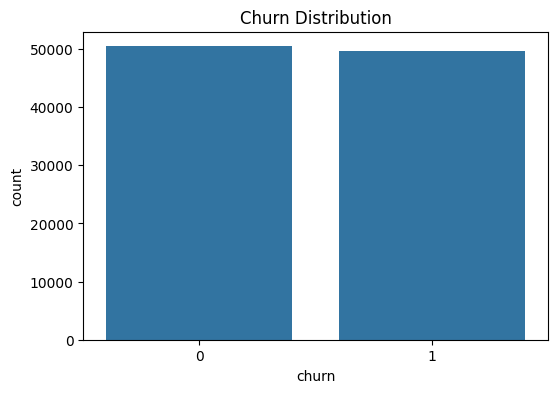

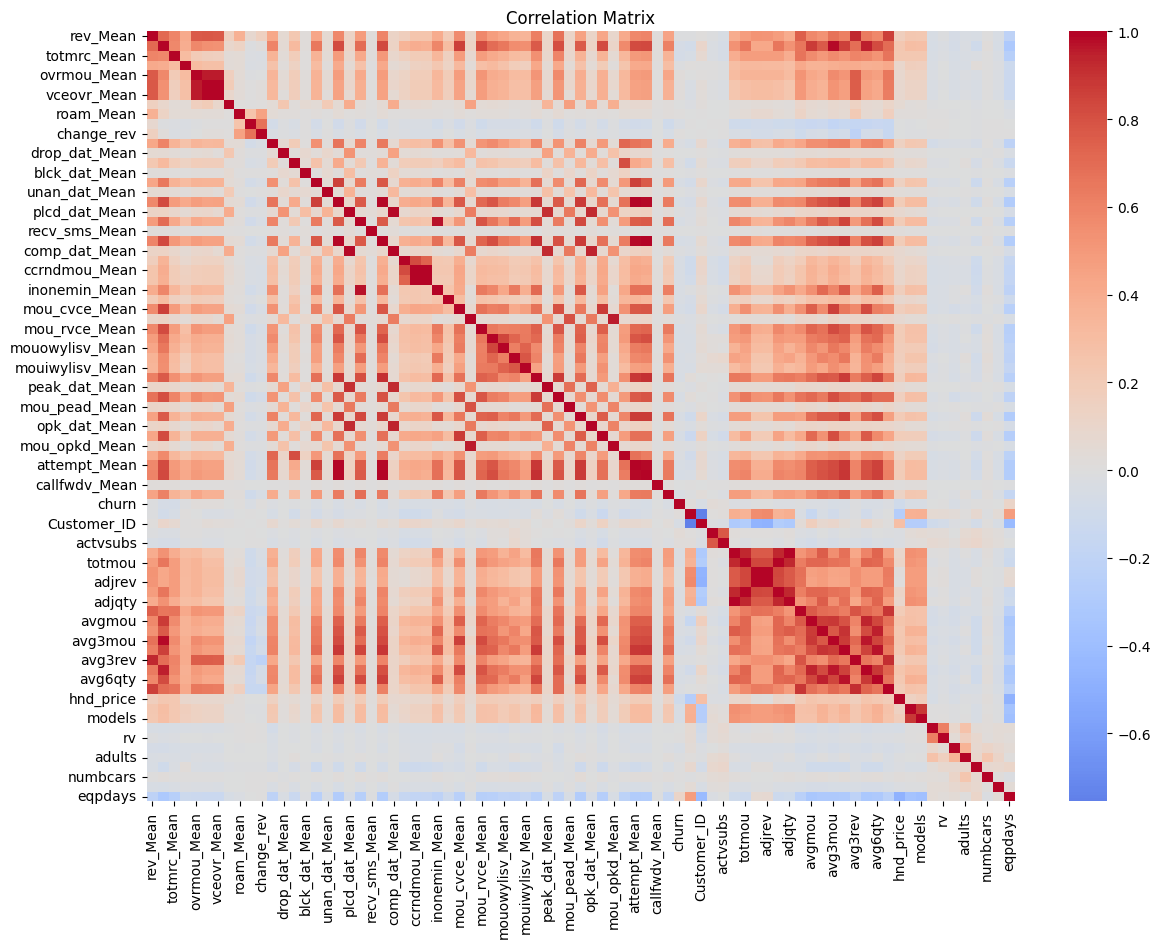

churn            1.000000
eqpdays          0.112691
uniqsubs         0.039882
vceovr_Mean      0.024240
ovrrev_Mean      0.023736
months           0.020991
ovrmou_Mean      0.019720
actvsubs         0.019686
roam_Mean        0.009324
change_rev       0.007832
income           0.005260
numbcars         0.002392
rv               0.000489
recv_sms_Mean   -0.000812
datovr_Mean     -0.001290
Name: churn, dtype: float64


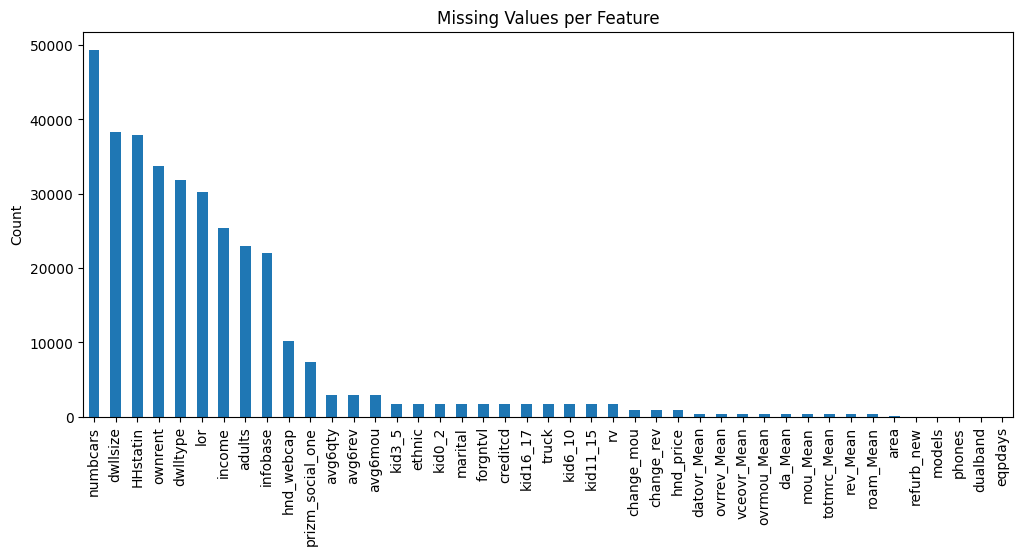

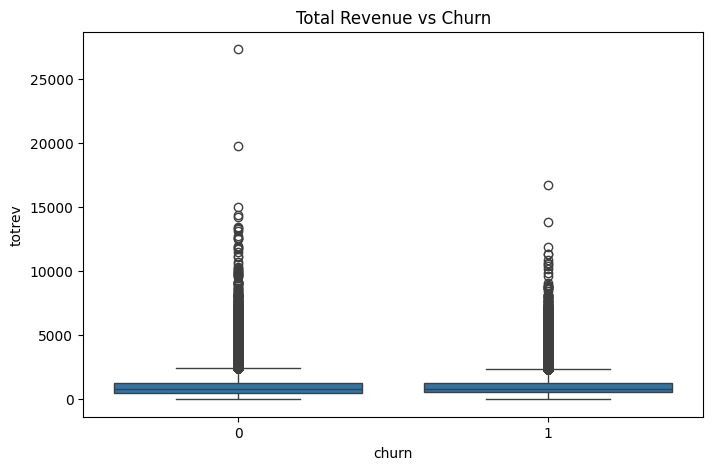

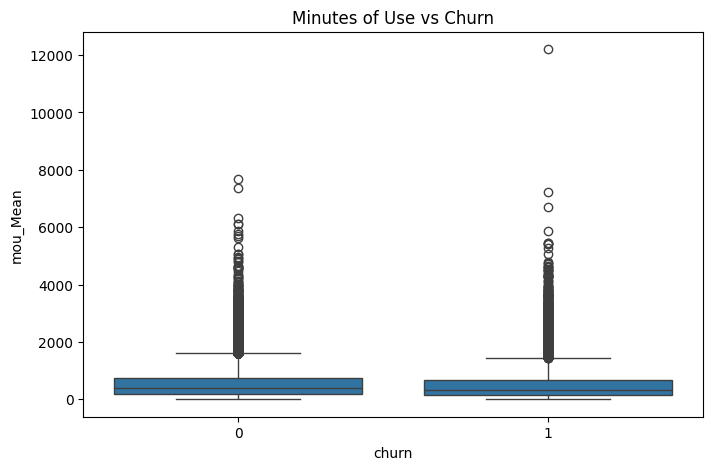

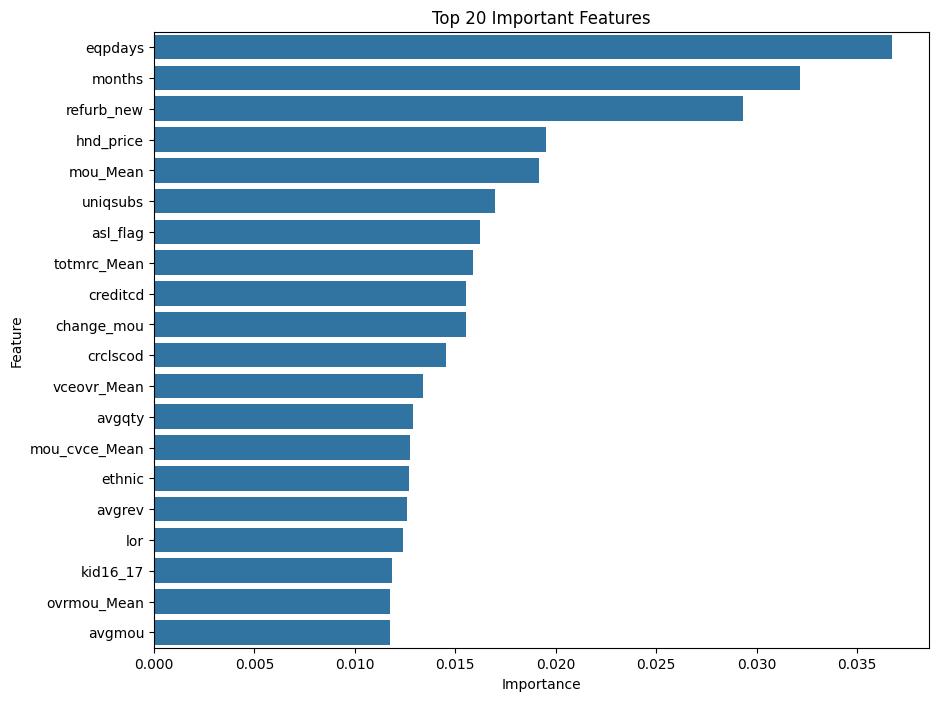

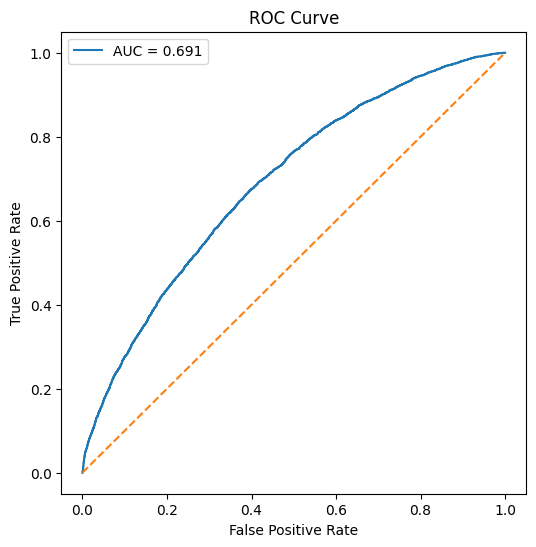

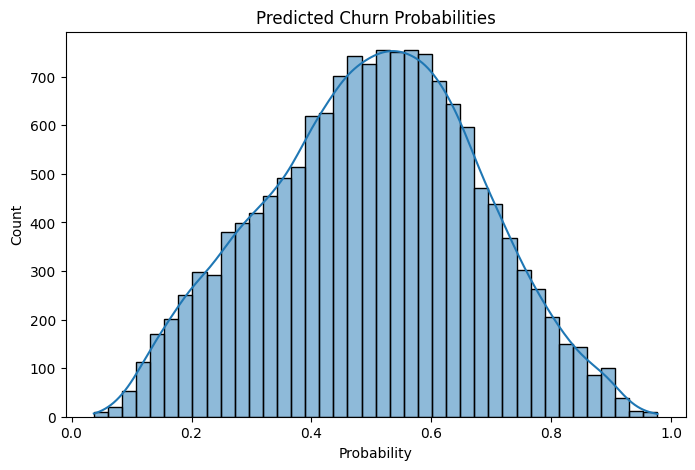

In [ ]:

if __name__ == "__main__":
    print("Running churn pipeline...")
    run_churn_pipeline()

loading datasets...
doing feature engineering...
making some graphs...


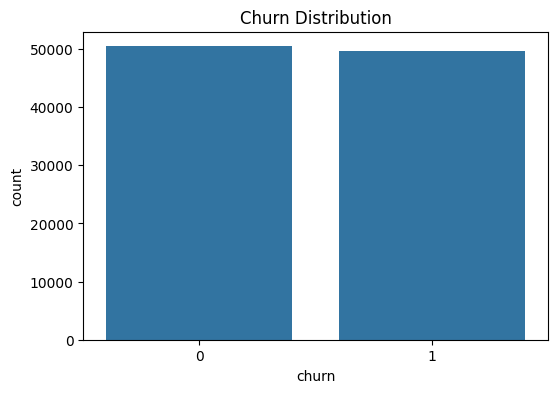

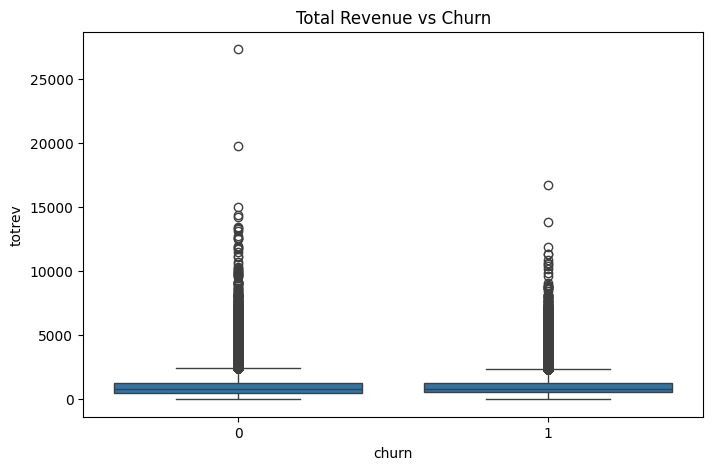

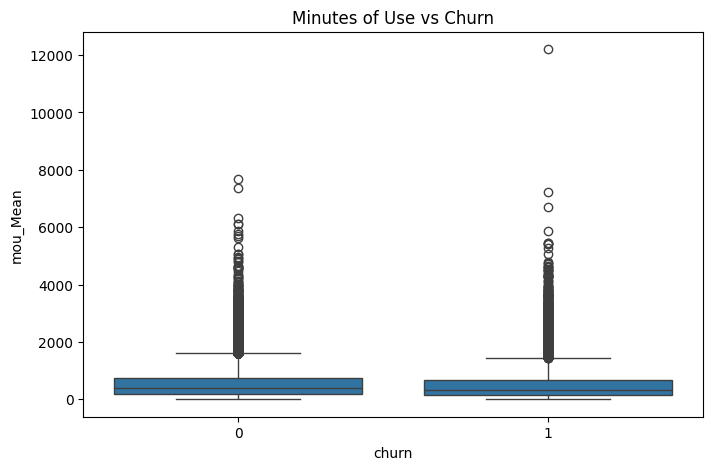

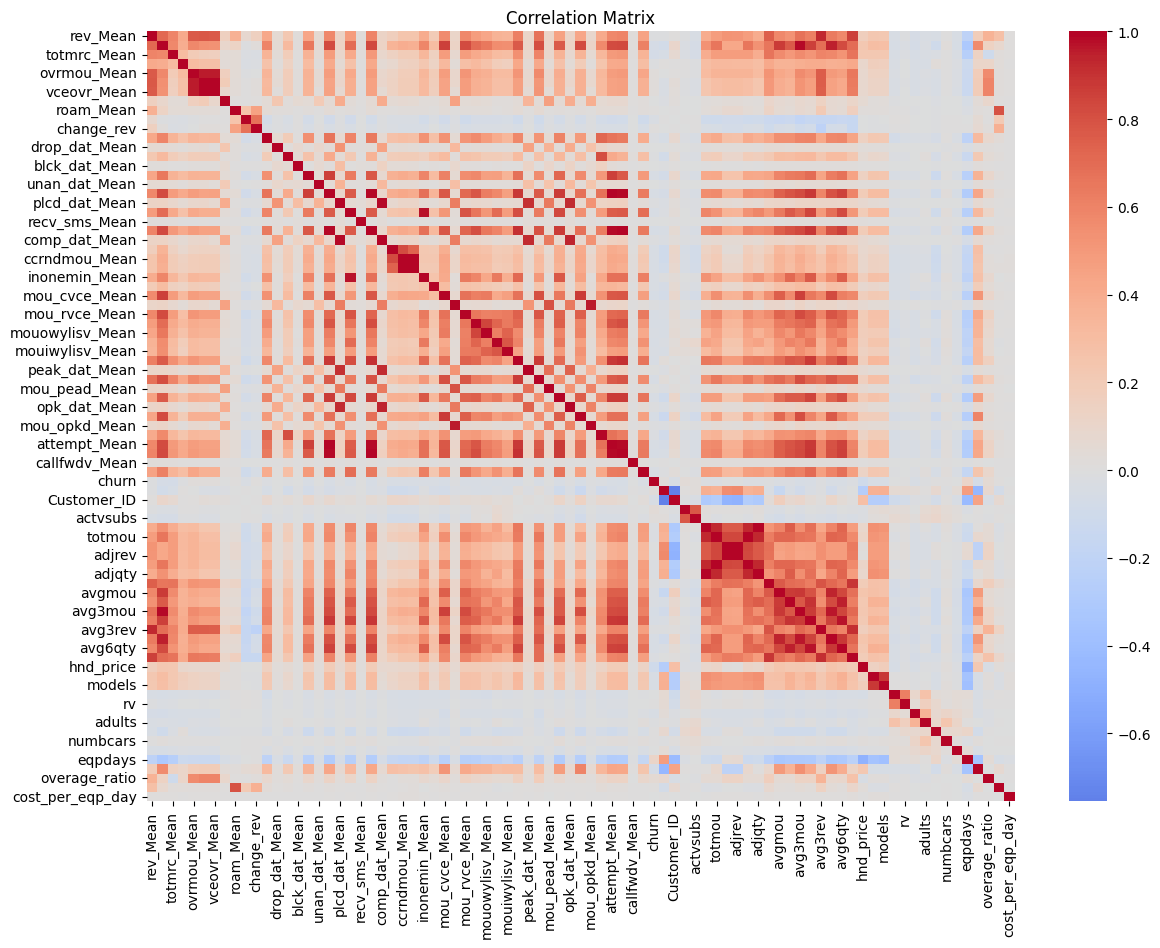

[I 2026-06-19 02:13:06,212] A new study created in memory with name: no-name-e19d5da3-e348-4c9b-8ef6-1648dbd56628


running optuna to find the best parameters...


[I 2026-06-19 02:14:56,594] Trial 0 finished with value: 0.6738250272286471 and parameters: {'iterations': 373, 'learning_rate': 0.02059095305959154, 'depth': 5, 'l2_leaf_reg': 1.1404734661980016}. Best is trial 0 with value: 0.6738250272286471.
[I 2026-06-19 02:20:07,381] Trial 1 finished with value: 0.683751334086516 and parameters: {'iterations': 555, 'learning_rate': 0.014621369571442073, 'depth': 8, 'l2_leaf_reg': 1.0507566940468236}. Best is trial 1 with value: 0.683751334086516.
[I 2026-06-19 02:24:55,482] Trial 2 finished with value: 0.6821035516781755 and parameters: {'iterations': 515, 'learning_rate': 0.01360371652581956, 'depth': 8, 'l2_leaf_reg': 6.329325289223854}. Best is trial 1 with value: 0.683751334086516.
[I 2026-06-19 02:28:13,610] Trial 3 finished with value: 0.6964128034802666 and parameters: {'iterations': 597, 'learning_rate': 0.09179812007131573, 'depth': 6, 'l2_leaf_reg': 9.470284609009783}. Best is trial 3 with value: 0.6964128034802666.
[I 2026-06-19 02:29:

training final model with 5-fold cross validation...
fold 1 done.
fold 2 done.
fold 3 done.
fold 4 done.
fold 5 done.

--- Final Test Metrics ---
ROC-AUC:   0.6972
Accuracy:  0.4965
Precision: 0.4960
Recall:    1.0000


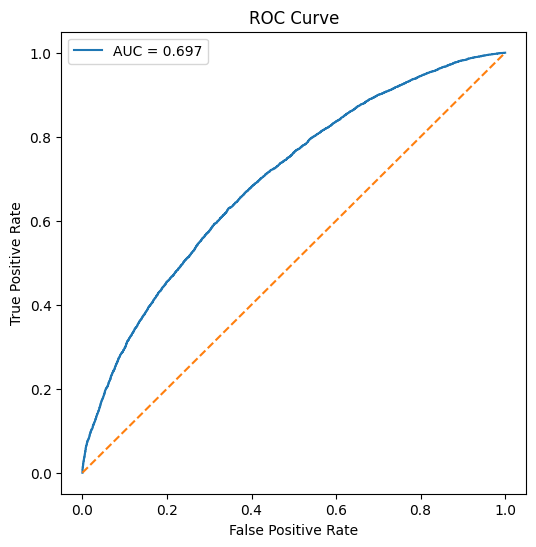

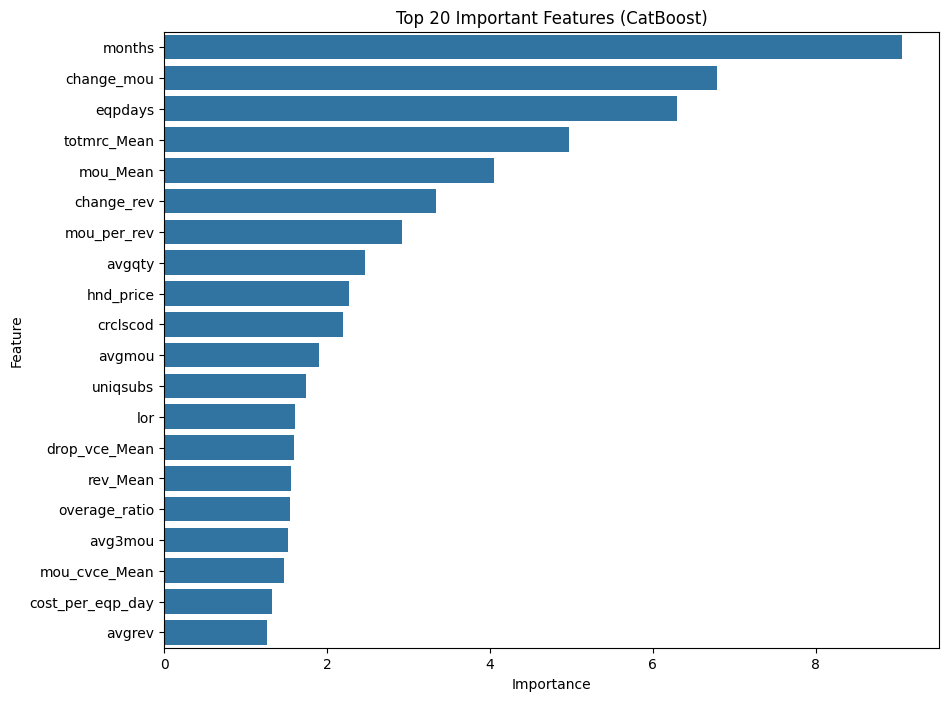

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
from catboost import CatBoostClassifier
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def run_advanced_pipeline():
    print("loading datasets...")
    client_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Client.csv')
    record_df = pd.read_csv('/content/drive/MyDrive/Final Assignment/telecom/Record.csv')
    data = pd.merge(record_df, client_df, on='Customer_ID', how='inner')

    print("doing feature engineering...")
    data['mou_per_rev'] = data['mou_Mean'] / (data['totrev'] + 1e-5)
    data['overage_ratio'] = data['ovrmou_Mean'] / (data['mou_Mean'] + 1e-5)
    data['roam_ratio'] = data['roam_Mean'] / (data['totrev'] + 1e-5)
    data['cost_per_eqp_day'] = data['totrev'] / (data['eqpdays'] + 1e-5)

    print("making some graphs...")

    # overall churn count
    plt.figure(figsize=(6,4))
    sns.countplot(x='churn', data=data)
    plt.title('Churn Distribution')
    plt.show()

    # revenue vs churn
    plt.figure(figsize=(8,5))
    sns.boxplot(x='churn', y='totrev', data=data)
    plt.title('Total Revenue vs Churn')
    plt.show()

    # minutes used vs churn
    plt.figure(figsize=(8,5))
    sns.boxplot(x='churn', y='mou_Mean', data=data)
    plt.title('Minutes of Use vs Churn')
    plt.show()

    # correlation map (numeric only)
    corr = data.select_dtypes(include=[np.number]).corr()
    plt.figure(figsize=(14,10))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.show()

    target = 'churn'
    X = data.drop(columns=['Customer_ID', target])
    y = data[target]

    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    X[cat_cols] = X[cat_cols].fillna('Missing').astype(str)
    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

    print("running optuna to find the best parameters...")
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'auto_class_weights': 'Balanced',
            'cat_features': cat_cols,
            'verbose': False,
            'eval_metric': 'AUC'
        }

        X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
        model = CatBoostClassifier(**params)
        model.fit(X_t, y_t, eval_set=[(X_v, y_v)], early_stopping_rounds=20)
        preds = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, preds)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    best_params['auto_class_weights'] = 'Balanced'
    best_params['cat_features'] = cat_cols
    best_params['verbose'] = False

    print("training final model with 5-fold cross validation...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**best_params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], early_stopping_rounds=30)
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
        print(f"fold {fold+1} done.")

    print("\n--- Final Test Metrics ---")
    C_FP = 150.0
    C_FN = 1360.0
    theta_opt = C_FP / (C_FP + C_FN)

    y_pred_opt = (test_preds >= theta_opt).astype(int)

    print(f"ROC-AUC:   {roc_auc_score(y_test, test_preds):.4f}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")

    # plot roc curve
    fpr, tpr, _ = roc_curve(y_test, test_preds)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,test_preds):.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # train one last time for feature importance
    final_model = CatBoostClassifier(**best_params)
    final_model.fit(X_train, y_train)

    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': final_model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(20)

    plt.figure(figsize=(10,8))
    sns.barplot(data=importance, x='Importance', y='Feature')
    plt.title('Top 20 Important Features (CatBoost)')
    plt.show()

if __name__ == "__main__":
    run_advanced_pipeline()